In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Dataset Overview and Structure Analysis

df = pd.read_csv(r"C:\Users\saira\Downloads\Walmart.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
# Data Cleaning and Missing Value Assessment

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.info()

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [5]:
total_sales = df["Weekly_Sales"].sum()
avg_sales = df["Weekly_Sales"].mean()
max_sales = df["Weekly_Sales"].max()

print("Total Sales:", total_sales)
print("Average Weekly Sales:", avg_sales)
print("Highest Weekly Sale:", max_sales)

Total Sales: 6737218987.11
Average Weekly Sales: 1046964.8775617715
Highest Weekly Sale: 3818686.45


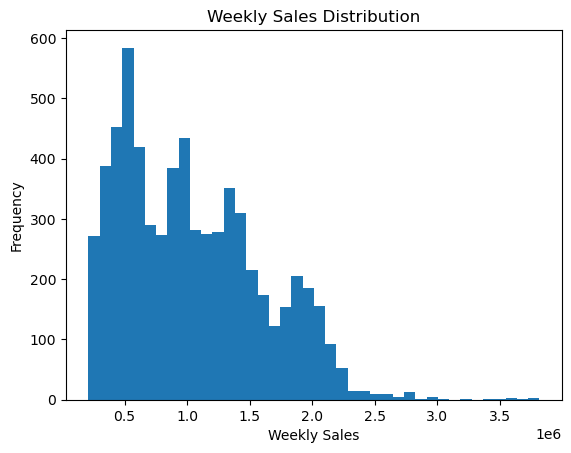

In [6]:
# Weekly Sales Distribution Analysis

plt.figure()
plt.hist(df["Weekly_Sales"], bins=40)

plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

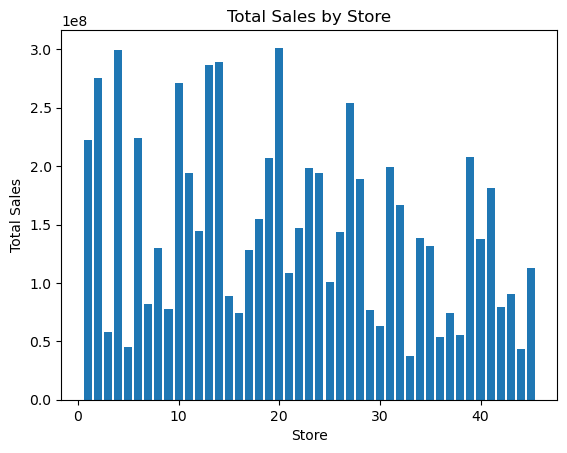

In [8]:
# Store-wise Sales Performance Analysis

store_sales = df.groupby("Store")["Weekly_Sales"].sum()
plt.figure()

plt.bar(store_sales.index, store_sales.values)

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

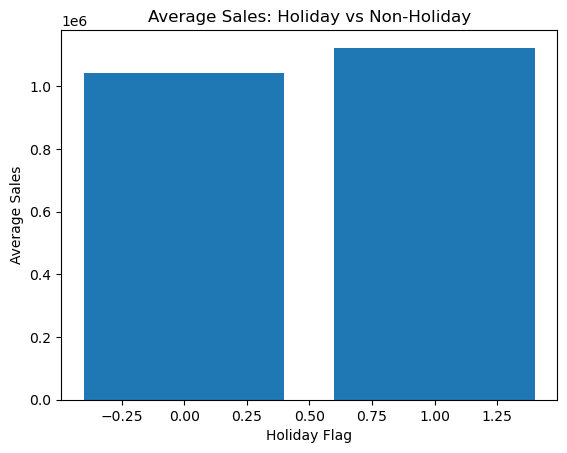

In [9]:
# Holiday vs Non-Holiday Sales Impact Analysis

holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
plt.figure()

plt.bar(holiday_sales.index, holiday_sales.values)

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Sales")

plt.show()

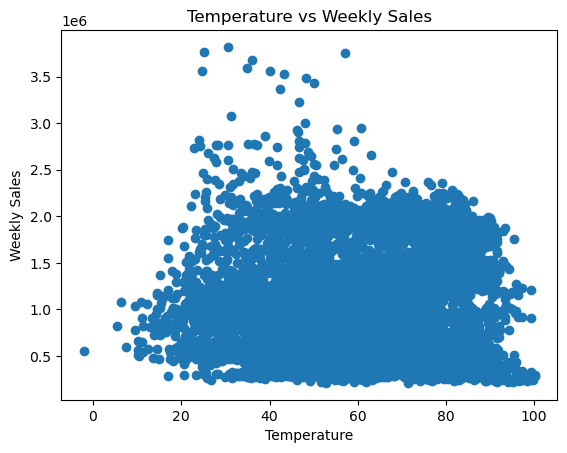

In [10]:
# Impact of Temperature on Weekly Sales

plt.figure()

plt.scatter(df["Temperature"], df["Weekly_Sales"])

plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

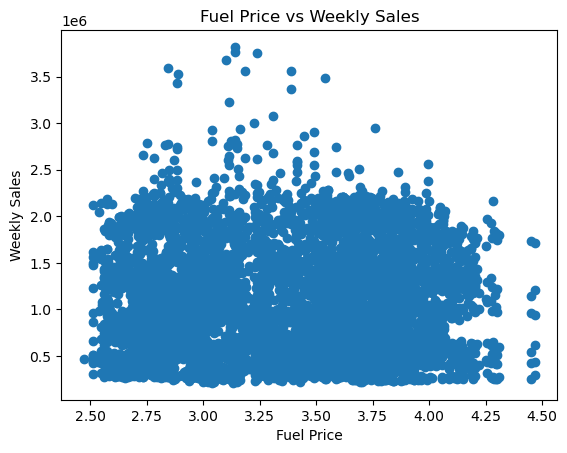

In [11]:
# Fuel Price Influence on Retail Sales

plt.figure()

plt.scatter(df["Fuel_Price"], df["Weekly_Sales"])

plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

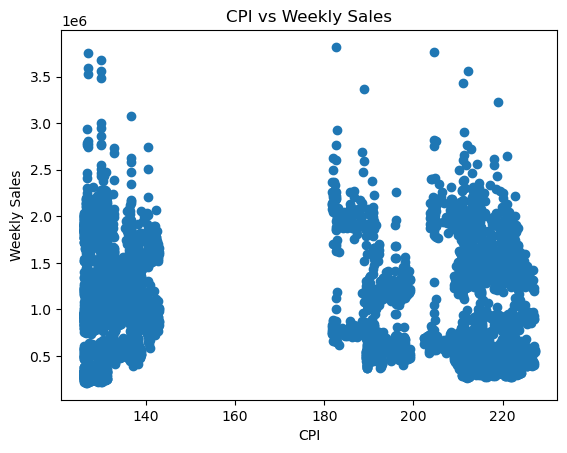

In [12]:
# Consumer Price Index (CPI) Impact on Sales

plt.figure()
plt.scatter(df["CPI"], df["Weekly_Sales"])

plt.title("CPI vs Weekly Sales")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")

plt.show()

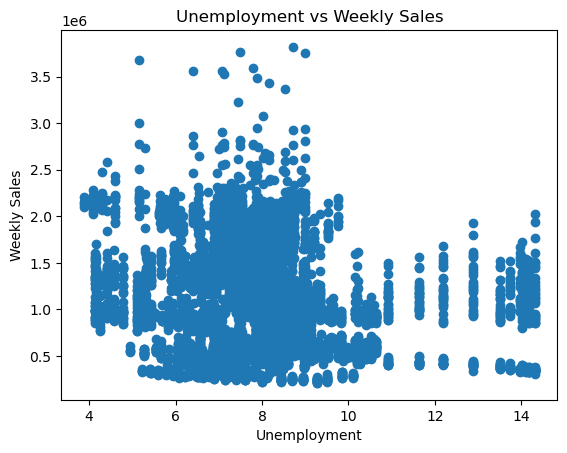

In [13]:
# Unemployment Rate vs Retail Sales Analysis

plt.figure()
plt.scatter(df["Unemployment"], df["Weekly_Sales"])

plt.title("Unemployment vs Weekly Sales")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")

plt.show()

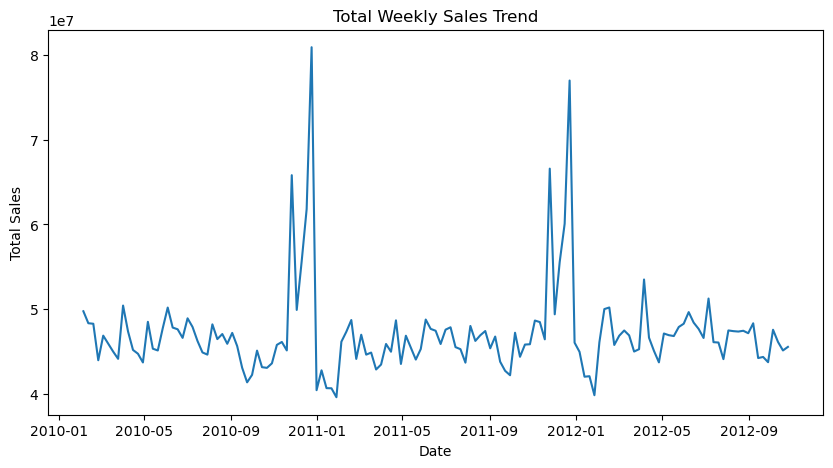

In [15]:
# Total Weekly Sales Trend

sales_trend = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(10,5))

plt.plot(sales_trend)

plt.title("Total Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

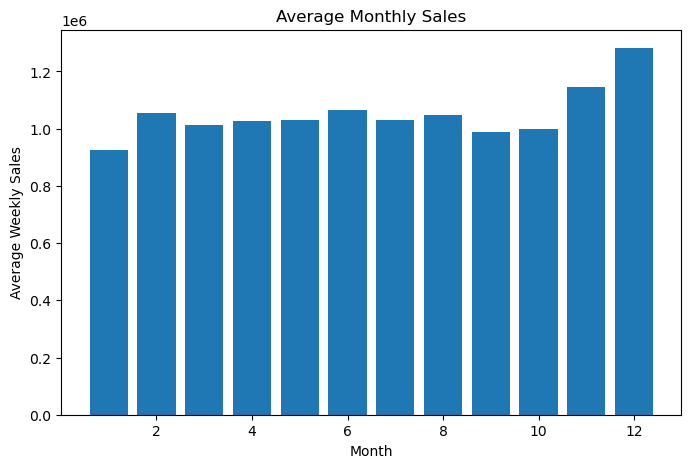

In [16]:
# Monthly Sales Trend and Seasonal Pattern Analysis

df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(8,5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.show()

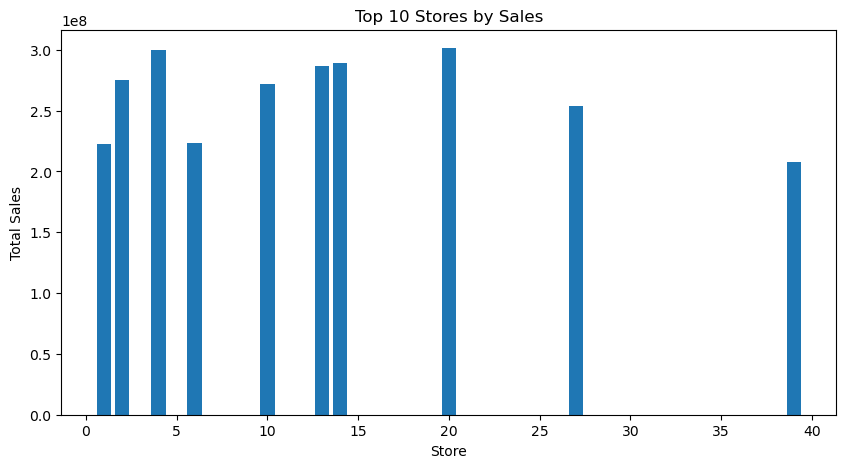

In [18]:
# Top Performing Stores Based on Total Revenue

store_sales = df.groupby("Store")["Weekly_Sales"].sum()
top10 = store_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top10.index, top10.values)

plt.title("Top 10 Stores by Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

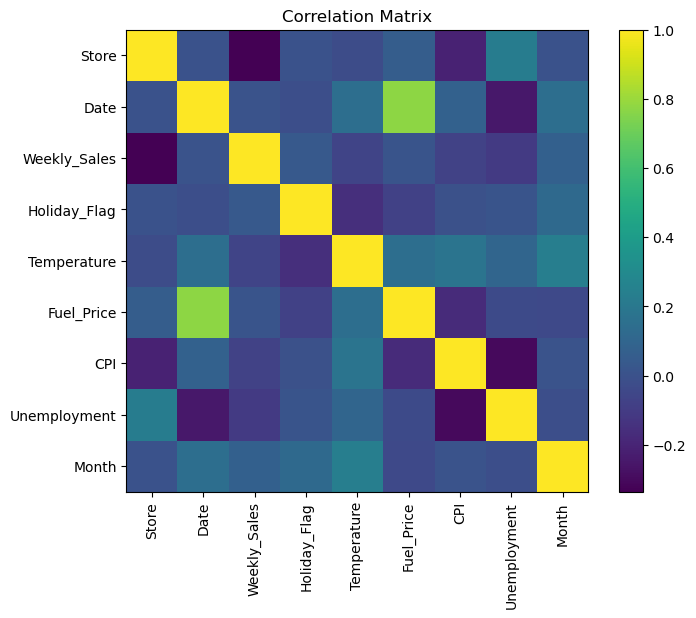

In [22]:
# Correlation Analysis Between Sales and Economic Indicators

correlation = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(correlation)
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()